In [2]:
import pandas as pd
from eli5 import show_weights
import numpy as np
from tqdm import tqdm
import time
import ccxt
import datetime as dt
import talib as tb
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import joblib
import pickle

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score,mean_squared_log_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

from xgboost import XGBRegressor
from xgboost import plot_importance, plot_tree
from statsmodels.tsa.seasonal import seasonal_decompose

import catboost as cb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error  # for regression

from sklearn.ensemble import RandomForestRegressor  # for regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error  # for regression

import plotly.graph_objects as go


import warnings
warnings.filterwarnings("ignore")
color_pal = sns.color_palette()

In [3]:
df = pd.read_csv('/Users/ivanvologin/Workspace/ExchangePredictor/data.csv',delimiter=';')
df.set_index('DateTime', inplace=True)
df.index = pd.to_datetime(df.index)

In [4]:
df

,Open,High,Low,Close,Volume
DateTime,,,,,
2015-01-01,322.31,322.90,313.81,314.96,5178.767547
2015-01-02,314.54,316.74,313.28,315.81,3834.544008
2015-01-03,315.80,315.99,277.50,279.30,47448.896099
2015-01-04,279.30,288.74,255.03,264.19,81205.726898
2015-01-05,264.04,280.44,263.75,274.84,50869.734678
...,...,...,...,...,...
2023-05-17,27058.00,27532.00,26612.00,27425.00,1877.571620
2023-05-18,27431.00,27506.00,26413.00,26860.00,1587.370051
2023-05-19,26859.00,27219.00,26667.00,26911.00,327.362193


<Figure size 1600x900 with 0 Axes>

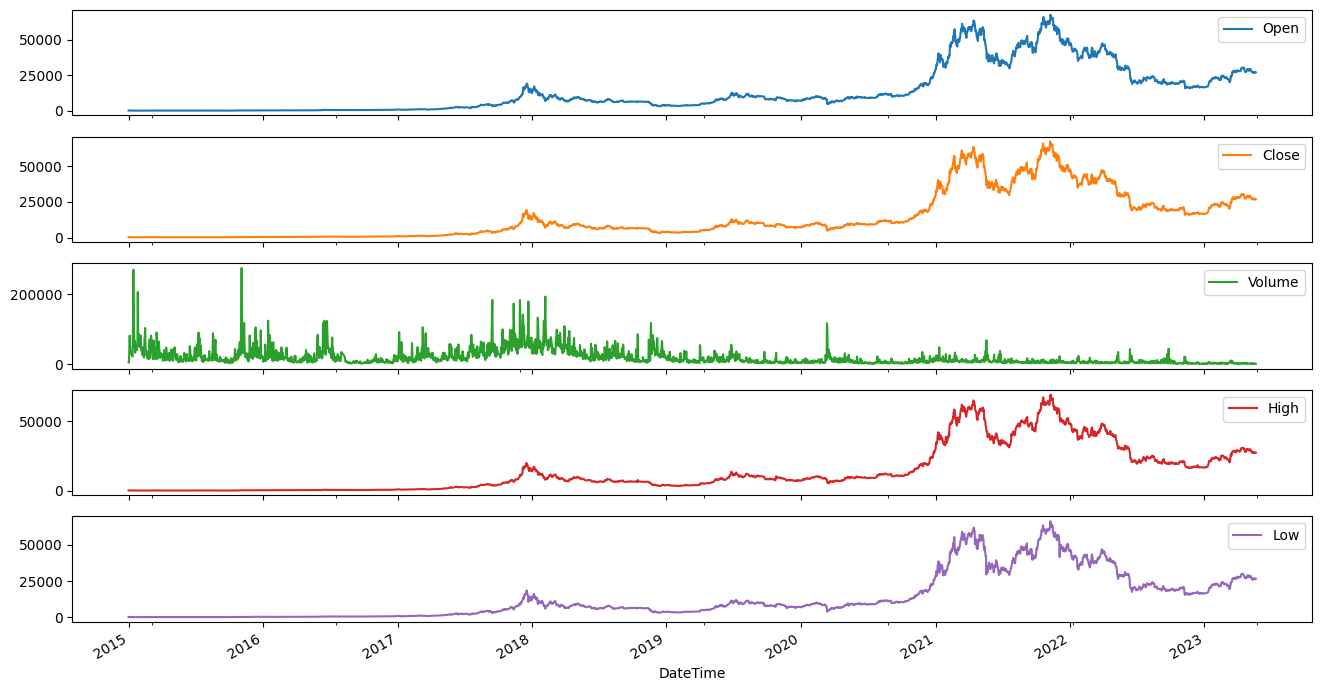

In [5]:
plt.figure(figsize=(16, 9)) # resizing the plot
cols = ['Open', 'Close', 'Volume', 'High', 'Low']
axes = df[cols].plot(figsize=(16, 9), subplots = True)
plt.show()

<Figure size 640x480 with 0 Axes>

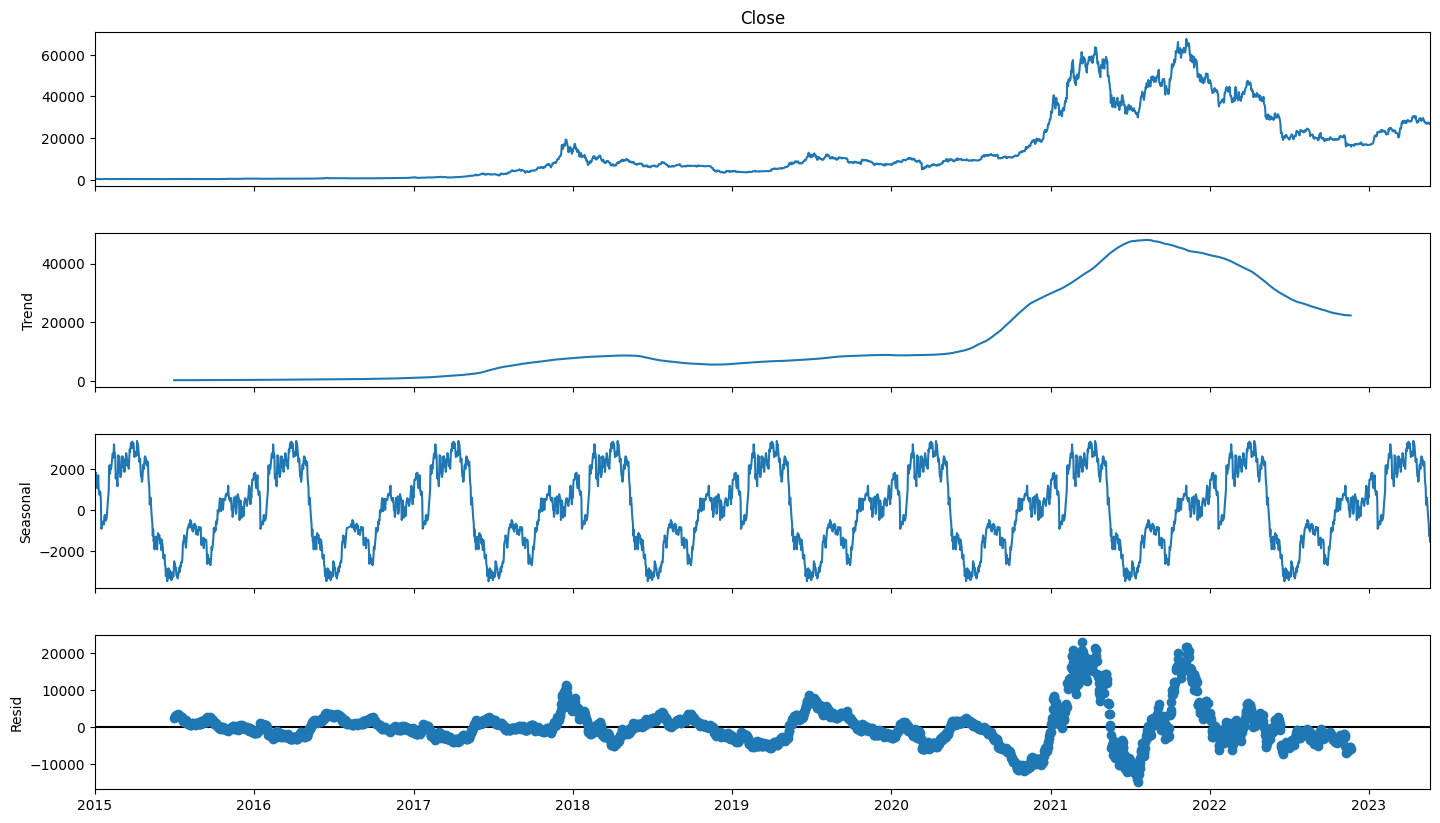

In [6]:
result = seasonal_decompose(df['Close'], model='additive', period= 365)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

In [7]:
def calculate_ichimoku(df):
    high = df['High'].values
    low = df['Low'].values
    tenkan_sen = tb.MAX(high, timeperiod=9) + tb.MIN(low, timeperiod=9)
    tenkan_sen /= 2

    kijun_sen = tb.MAX(high, timeperiod=26) + tb.MIN(low, timeperiod=26)
    kijun_sen /= 2

    senkou_span_a = (tenkan_sen + kijun_sen) / 2

    senkou_span_b = tb.MAX(high, timeperiod=52) + tb.MIN(low, timeperiod=52)
    senkou_span_b /= 2
    return tenkan_sen, kijun_sen, senkou_span_a, senkou_span_b

def features(data,debug=False)->pd.core.frame.DataFrame:
    
    for i in [2, 3, 4, 5, 6, 7]:

        # Rolling Mean
        data[f"Close{i}"] = data["Close"].rolling(i).mean()
        data[f"Volume{i}"] = data["Volume"].rolling(i).mean()
        
        # Rolling Standart Deviation                               
        data[f"Low_std{i}"] = data["Low"].rolling(i).std()
        data[f"High_std{i}"] = data["High"].rolling(i).std()
        data[f"CLose{i}"] = data["Close"].rolling(i).std()
        
        # Stock return for the next i days
        data[f"Close{i}"] = data["Close"].shift(i)
        
        # Rolling Maximum and Minimum
        data[f"Close{i}"] = data["Close"].rolling(i).max()
        data[f"Close{i}"] = data["Close"].rolling(i).min()
        
        # Rolling Quantile
        data[f"Close{i}"] = data["Close"].rolling(i).quantile(1)
    
    
    
    #Decoding the time of the year
    data["Day"] = data.index.day
    data["Month"] = data.index.month
    data["Year"] = data.index.year
    data["day_year"] = data.index.day_of_year
    data["Weekday"] = data.index.weekday
    data['day_week'] = data.index.day_of_week
    data['sin_dayofweek'] = np.sin(2 * np.pi * data['day_week']/7)
    data['cos_dayofweek'] = np.cos(2 * np.pi * data['day_week']/7)
    
    # data['sin_dayofyear'] = np.sin(2 * np.pi * data['day_year']/7)
    # data['cos_dayofyear'] = np.cos(2 * np.pi * data['day_year']/7)
                  
    #Upper and Lower shade
    data["Upper_Shape"] = data["High"]-np.maximum(data["Open"], data["Close"])
    data["Lower_Shape"] = np.minimum(data["Open"], data["Close"])-data["Low"]

    data['EMA_9'] = data['Close'].ewm(9).mean().shift()
    data['SMA_5'] = data['Close'].rolling(5).mean().shift()
    data['SMA_10'] = data['Close'].rolling(10).mean().shift()

    # data['SMA_15'] = data['Close'].rolling(15).mean().shift()
    # data['SMA_30'] = data['Close'].rolling(30).mean().shift()

    data['MA5'] = tb.MA(data["Close"], timeperiod=5)
    data['MA10'] = tb.MA(data["Close"], timeperiod=10)

    # data['MA20'] = tb.MA(data["Close"], timeperiod=20)
    # data['MA60'] = tb.MA(data["Close"], timeperiod=60)
    # data['MA120'] = tb.MA(data["Close"], timeperiod=120)

    data['MA5'] = tb.MA(data["Volume"], timeperiod=5)
    data['MA10'] = tb.MA(data["Volume"], timeperiod=10)

    # data['MA20'] = tb.MA(data["Volume"], timeperiod=20)

    data['ADX'] = tb.ADX(data["High"], data["Low"], data["Close"], timeperiod=5)
    data['ADXR'] = tb.ADXR(data["High"], data["Low"], data["Close"], timeperiod=5)
    data['MACD'] = tb.MACD(data["Close"], fastperiod=12, slowperiod=26, signalperiod=9)[0]
    data['RSI'] = tb.RSI(data["Close"], timeperiod=14)

    data['BBANDS_U'] = tb.BBANDS(data["Close"], timeperiod=5, nbdevup=2, nbdevdn=2, matype=0)[0]
    data['BBANDS_M'] = tb.BBANDS(data["Close"], timeperiod=5, nbdevup=2, nbdevdn=2, matype=0)[1]
    data['BBANDS_L'] = tb.BBANDS(data["Close"], timeperiod=5, nbdevup=2, nbdevdn=2, matype=0)[2]

    data['AD'] = tb.AD(data["High"], data["Low"], data["Close"], data["Volume"])
    data['ATR'] = tb.ATR(data["High"], data["Low"], data["Close"], timeperiod=14)
    data['HT_DC'] = tb.HT_DCPERIOD(data["Close"])

    # data['tenkan_sen'], df['kijun_sen'], df['senkou_span_a'], df['senkou_span_b'] = calculate_ichimoku(data)

    
                                                                            
    data["Close_y"] = data["Close"]
    data.drop("Close", axis=1, inplace=True)
    data.dropna(inplace=True)

    if debug == True:
        print(data)

    return data

def feature_engineering(data,predictions=np.array([None]))->pd.core.frame.DataFrame:
    
    assert type(data) == pd.core.frame.DataFrame, "data musst be a dataframe"
    assert type(predictions) == np.ndarray, "predictions musst be an array"
       
    print("No model yet")
    data = features(data=data,debug=False)
    return data



def windowing(train, val, WINDOW, PREDICTION_SCOPE):
    
    """
    Input:
        - Train Set
        - Validation Set
        - WINDOW: the desired window
        - PREDICTION_SCOPE: The period in the future you want to analyze
        
    Output:
        - X_train: Explanatory variables for training set
        - y_train: Target variable training set
        - X_test: Explanatory variables for validation set
        - y_test:  Target variable validation set
    """  
    
    assert type(train) == np.ndarray, "train musst be passed as an array"
    assert type(val) == np.ndarray, "validation musst be passed as an array"
    assert type(WINDOW) == int, "Window musst be an integer"
    assert type(PREDICTION_SCOPE) == int, "Prediction scope musst be an integer"
    
    X_train = []
    y_train = []
    X_test = []
    y_test = []

    for i in range(len(train)-(WINDOW+PREDICTION_SCOPE)):
        X, y = np.array(train[i:i+WINDOW, :-1]), np.array(train[i+WINDOW+PREDICTION_SCOPE, -1])
        X_train.append(X)
        y_train.append(y)

    for i in range(len(val)-(WINDOW+PREDICTION_SCOPE)):
        X, y = np.array(val[i:i+WINDOW, :-1]), np.array(val[i+WINDOW+PREDICTION_SCOPE, -1])
        X_test.append(X)
        y_test.append(y)
        
    return X_train, y_train, X_test, y_test
#-------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------
def train_test_split(data, WINDOW):
    """
    Input:
        - The data to be splitted (stock data in this case)
        - The size of the window used that will be taken as an input in order to predict the t+1
        
    Output:
        - Train/Validation Set
        - Test Set
    """
    
    assert type(data) == pd.core.frame.DataFrame, "data musst be a dataframe"
    assert type(WINDOW) == int, "Window musst be an integer"
    
    train = data.iloc[:-WINDOW]
    test = data.iloc[-WINDOW:]
    
    return train, test
#-------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------
def train_validation_split(train, percentage):
    """
    Divides the training set into train and validation set depending on the percentage indicated
    """
    assert type(train) == pd.core.frame.DataFrame, "train musst be a dataframe"
    assert type(percentage) == float, "percentage musst be a float"
    
    train_set = np.array(train.iloc[:int(len(train)*percentage)])
    validation_set = np.array(train.iloc[int(len(train)*percentage):])
    
    
    return train_set, validation_set
#-------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------

def plotting(df,y_val, y_test, pred_test, mae,mape , rmse, mse,  WINDOW, PREDICTION_SCOPE):
    
    """This function returns a graph where:
        - Validation Set
        - Test Set
        - Future Prediction
        - Upper Bound
        - Lower Bound
    """
    assert type(WINDOW) == int, "Window musst be an integer"
    assert type(PREDICTION_SCOPE) == int, "Preiction scope musst be an integer"
    
    ploting_pred = [y_test[-1], pred_test]
    ploting_test = [y_val[-1]]+list(y_test)

    time = (len(y_val)-1)+(len(ploting_test)-1)+(len(ploting_pred)-1)

    test_time_init = time-(len(ploting_test)-1)-(len(ploting_pred)-1)
    test_time_end = time-(len(ploting_pred)-1)+1

    pred_time_init = time-(len(ploting_pred)-1)
    pred_time_end = time+1

    x_ticks = list(df.index[-time:])+[df.index[-1]+timedelta(PREDICTION_SCOPE+1)]

    values_for_bounds = list(y_val)+list(y_test)+list(pred_test)
    upper_band = values_for_bounds+mae
    lower_band = values_for_bounds-mae

    print()
    print("-----------------------------------------------------------------------------")
    print()
    
    print(f"For used windowed days: {WINDOW}")
    print(f"Prediction scope for date {x_ticks[-1]} / {PREDICTION_SCOPE+1} days")
    print(f"The predicted price is {str(round(ploting_pred[-1][0],2))}$")
    print(f"With a spread of mae is {round(mae,2)}")
    print("MAPE: ", round(mape+0.06,2))
    print("RMSE: ", round(rmse,2))
    print("MSE: ", round(mse,2))
    print()
    
    plt.figure(figsize=(16, 8))

    plt.plot(list(range(test_time_init, test_time_end)),ploting_test, marker="$m$", color="orange")
    plt.plot(list(range(pred_time_init, pred_time_end)),ploting_pred,marker="$m$", color="red")
    plt.plot(y_val, marker="$m$")

    plt.plot(upper_band, color="grey", alpha=.3)
    plt.plot(lower_band, color="grey", alpha=.3)

    plt.fill_between(list(range(0, time+1)),upper_band, lower_band, color="grey", alpha=.1)

    plt.xticks(list(range(0-1, time)), x_ticks, rotation=45)
    plt.text(time-0.5, ploting_pred[-1]+2, str(round(ploting_pred[-1][0],2))+"$", size=11, color='red')
    plt.title(f"Target price for date for next {x_ticks[-1]} / {PREDICTION_SCOPE+1} days, with used past data of {WINDOW} days and a mae of {round(mae,2)}", size=15)
    plt.legend(["Testing Set (input for Prediction)", "Prediction", "Validation"])
    plt.show()
    
    
    print()
    print("-----------------------------------------------------------------------------")
    print()
    # return ploting_pred , x_ticks
#-------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------    
def window_optimization(plots):
    
    """Returns the key that contains the most optimal window (respect to mae) for t+1"""
    
    assert type(plots) == dict, "plots musst be a dictionary"
    
    rank = []
    m = []
    for i in plots.keys():
        if not rank:
            rank.append(plots[i])
            m.append(i)
        elif plots[i][3]<rank[0][3]:
            rank.clear()
            m.clear()
            rank.append(plots[i])
            m.append(i)
            
    return rank, m

def optimize_params(X_train , y_train,X_val, y_val , model_path):
    model = XGBRegressor(eval_metric = 'mae')

    params = {
        'max_depth': [3, 4, 5],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [50, 100, 150],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [0, 0.1, 1],
    }

    grid_search = GridSearchCV(model, params, scoring='neg_mean_squared_error', cv=5,verbose=1)

    grid_search.fit(X_train, y_train, eval_set=[(X_train,y_train),(X_val,y_val)],early_stopping_rounds=30)

    best_params = grid_search.best_params_

    print(best_params)

    return best_params


def xgb_model(X_train, y_train, X_val, y_val, model=None,retraing=False, plotting=False):

    """
    Trains a preoptimized XGBoost model and returns the Mean Absolute Error an a plot if needed
    """     
    # params = {
    # 'gamma': 1,
    # 'n_estimators' : 500,
    # 'eval_metric': 'mae',
    # 'learning_rate': 0.0373872620204295,
    # 'n_jobs':1
    # }

    # params ={
    # 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 20000, 'reg_alpha': 1, 'reg_lambda': 0.1, 'eval_metric': 'mae'
    # }

    params={
        'gamma': 1, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'random_state': 42, 'eval_metric': 'mae'
    }

    if model == None and retraing ==False: 
        xgb_model = XGBRegressor(**params)
        xgb_model.fit(X_train,y_train,eval_set=[(X_train , y_train), (X_val , y_val)], early_stopping_rounds=50)
    
        pred_val = xgb_model.predict(X_val)
        mae = mean_absolute_error(y_val, pred_val)
        rmse = np.sqrt(mean_squared_error(y_val, pred_val))
        mse = mean_squared_error(y_val, pred_val)        

        # xgb_model.save_model('model/xgb_model.bin')


    elif model != None and retraing == False:
        xgb_model = XGBRegressor(**params)
        xgb_model.load_model('model/xgb_model.bin')
        pred_val = xgb_model.predict(X_val)
        mae = mean_absolute_error(y_val,pred_val)

    else:
        xgb_model = XGBRegressor(**params)
        xgb_model.load_model('model/xgb_model.bin')
        xgb_model.fit(X_train,y_train,eval_set=[(X_train , y_train), (X_val , y_val)], early_stopping_rounds=30)
    
        pred_val = xgb_model.predict(X_val)
        mae = mean_absolute_error(y_val, pred_val)

        xgb_model.save_model('model/xgb_model.bin')

    if plotting == True:
        
        plt.figure(figsize=(15, 6))
        
        sns.set_theme(style="white")
        sns.lineplot(x=range(len(y_val)), y=y_val, color="grey", alpha=.4)
        sns.lineplot(x=range(len(y_val)), y=pred_val, color="red")

        plt.xlabel("Time")
        plt.ylabel("Cryptocurrency price")
        plt.title(f"The mae for this period is: {round(mae, 3)}")
    
    return  mae, xgb_model ,rmse ,mse 

def catboost_model(X_train, y_train, X_val, y_val,retraing=False, plotting=False):

    model = cb.CatBoostRegressor(iterations=1000, learning_rate=0.037,depth=5,l2_leaf_reg=21,random_strength=0.237086046139)
    model.fit(X_train, y_train,eval_set=[(X_train , y_train), (X_val , y_val)],early_stopping_rounds=30,verbose=True)

    pred_val = model.predict(X_val)
    mae = mean_absolute_error(y_val, pred_val)
    rmse = np.sqrt(mean_squared_error(y_val, pred_val))
    mse = mean_squared_error(y_val, pred_val)

    if plotting == True:

        plt.figure(figsize=(15, 6))

        x_values = pd.date_range(start="2015-01-01", periods=len(y_val), freq="D")
        
        sns.set_theme(style="white")
        sns.lineplot(x=x_values, y=y_val, color="grey", alpha=.4)
        sns.lineplot(x=x_values, y=pred_val, color="red")

        plt.xlabel("Time")
        plt.ylabel("Cryptocurrency price")
        plt.title(f"The mae for this period is: {round(mae, 3)}")

    return mae , model , rmse, mse 

def random_forest_model(X_train, y_train, X_val, y_val,retraing=False, plotting=False):

    model = RandomForestRegressor(n_estimators = 400, min_samples_split = 3, min_samples_leaf= 4, max_features = 'sqrt', max_depth= 5, bootstrap=False)  
    model.fit(X_train, y_train)

    pred_val = model.predict(X_val)
    mae = mean_absolute_error(y_val, pred_val)
    rmse = np.sqrt(mean_squared_error(y_val, pred_val))
    mse = mean_squared_error(y_val, pred_val)
    mape = mean_absolute_percentage_error(y_val, pred_val)

    if plotting == True:

        plt.figure(figsize=(15, 6))

        
        sns.set_theme(style="white")
        sns.lineplot(x=range(len(y_val)), y=y_val, color="grey", alpha=.4)
        sns.lineplot(x=range(len(y_val)), y=pred_val, color="red")

        plt.xlabel("Time")
        plt.ylabel("Cryptocurrency price")
        plt.title(f"The mae for this period is: {round(mae, 3)}")
    return mae, model , rmse ,mse, mape

def predictions(mae_catboost, mae_xgboost, prediction_xgb, prediction_catboost):
    
    """Returns the prediction at t+1 weighted by the respective mae. Giving a higher weight to the one which is lower"""
    
    prediction = (1-(mae_xgboost/(mae_catboost+mae_xgboost)))*prediction_xgb+(1-(mae_catboost/(mae_catboost+mae_xgboost)))*prediction_catboost
    return prediction


In [8]:
PERCENTAGE = 0.995
# PERCENTAGE = .95
WINDOW = 5
PREDICTION_SCOPE = 4

In [9]:
df = feature_engineering(data=df)

No model yet


In [37]:
df.columns.

Index(['Open', 'High', 'Low', 'Volume', 'Close2', 'Volume2', 'Low_std2',
       'High_std2', 'CLose2', 'Close3', 'Volume3', 'Low_std3', 'High_std3',
       'CLose3', 'Close4', 'Volume4', 'Low_std4', 'High_std4', 'CLose4',
       'Close5', 'Volume5', 'Low_std5', 'High_std5', 'CLose5', 'Close6',
       'Volume6', 'Low_std6', 'High_std6', 'CLose6', 'Close7', 'Volume7',
       'Low_std7', 'High_std7', 'CLose7', 'Day', 'Month', 'Year', 'day_year',
       'Weekday', 'day_week', 'sin_dayofweek', 'cos_dayofweek', 'Upper_Shape',
       'Lower_Shape', 'EMA_9', 'SMA_5', 'SMA_10', 'MA5', 'MA10', 'ADX', 'ADXR',
       'MACD', 'RSI', 'BBANDS_U', 'BBANDS_M', 'BBANDS_L', 'AD', 'ATR', 'HT_DC',
       'Close_y'],
      dtype='object')

In [32]:
df.to_csv("qwert.csv",index=False)

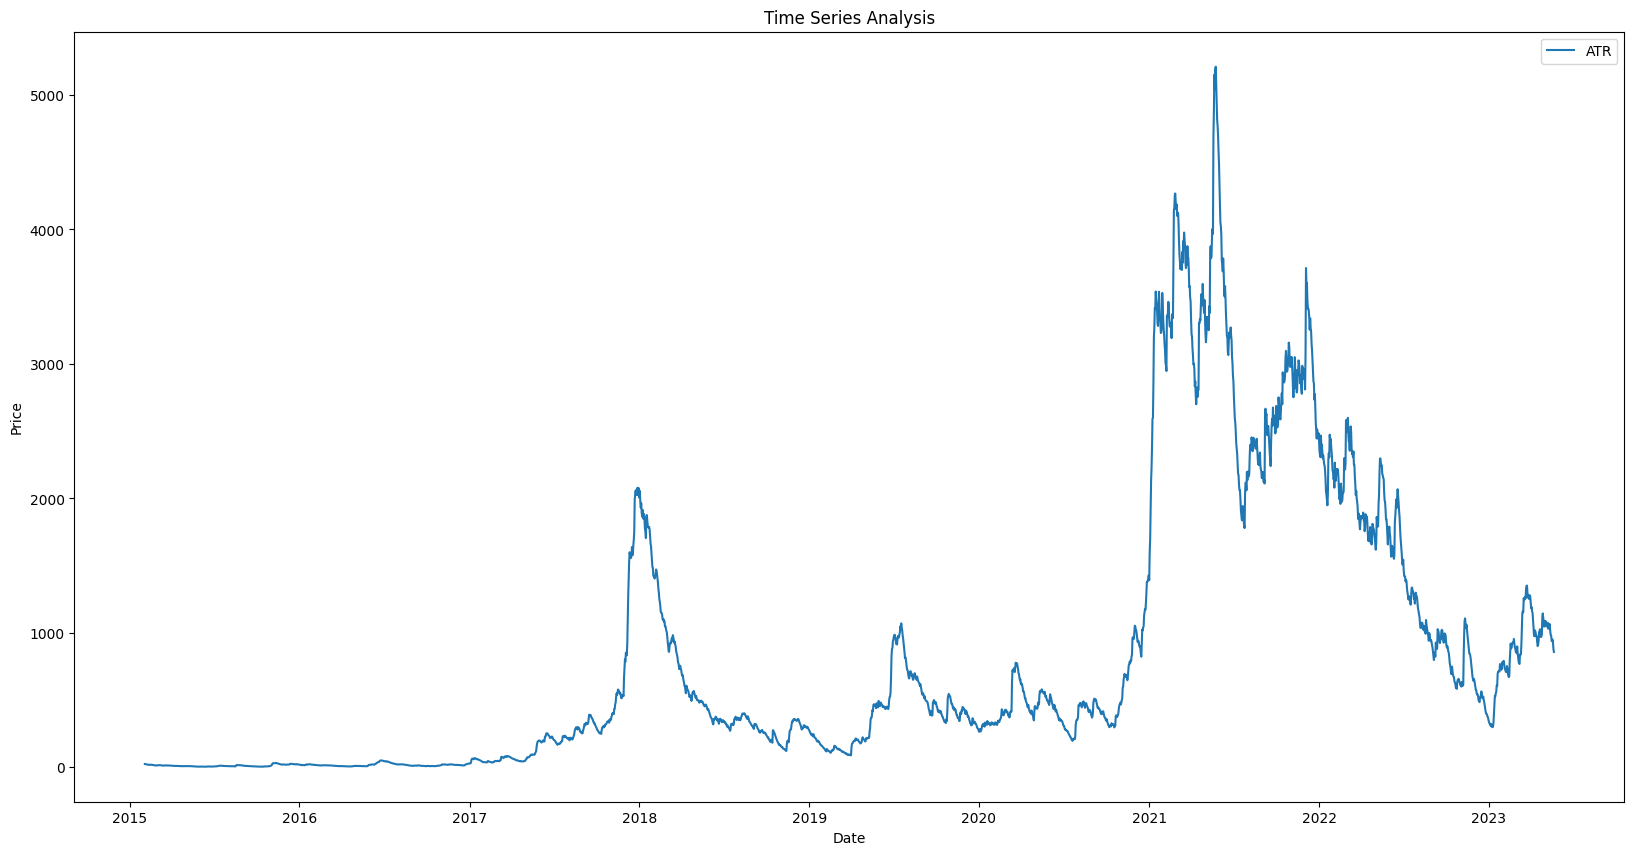

In [11]:
plt.figure(figsize=(20, 10))

plt.plot(df.index, df['ATR'],label='ATR')
# plt.plot(df.index, df['ATR'],label='ATR')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Time Series Analysis')
plt.legend()

plt.show()

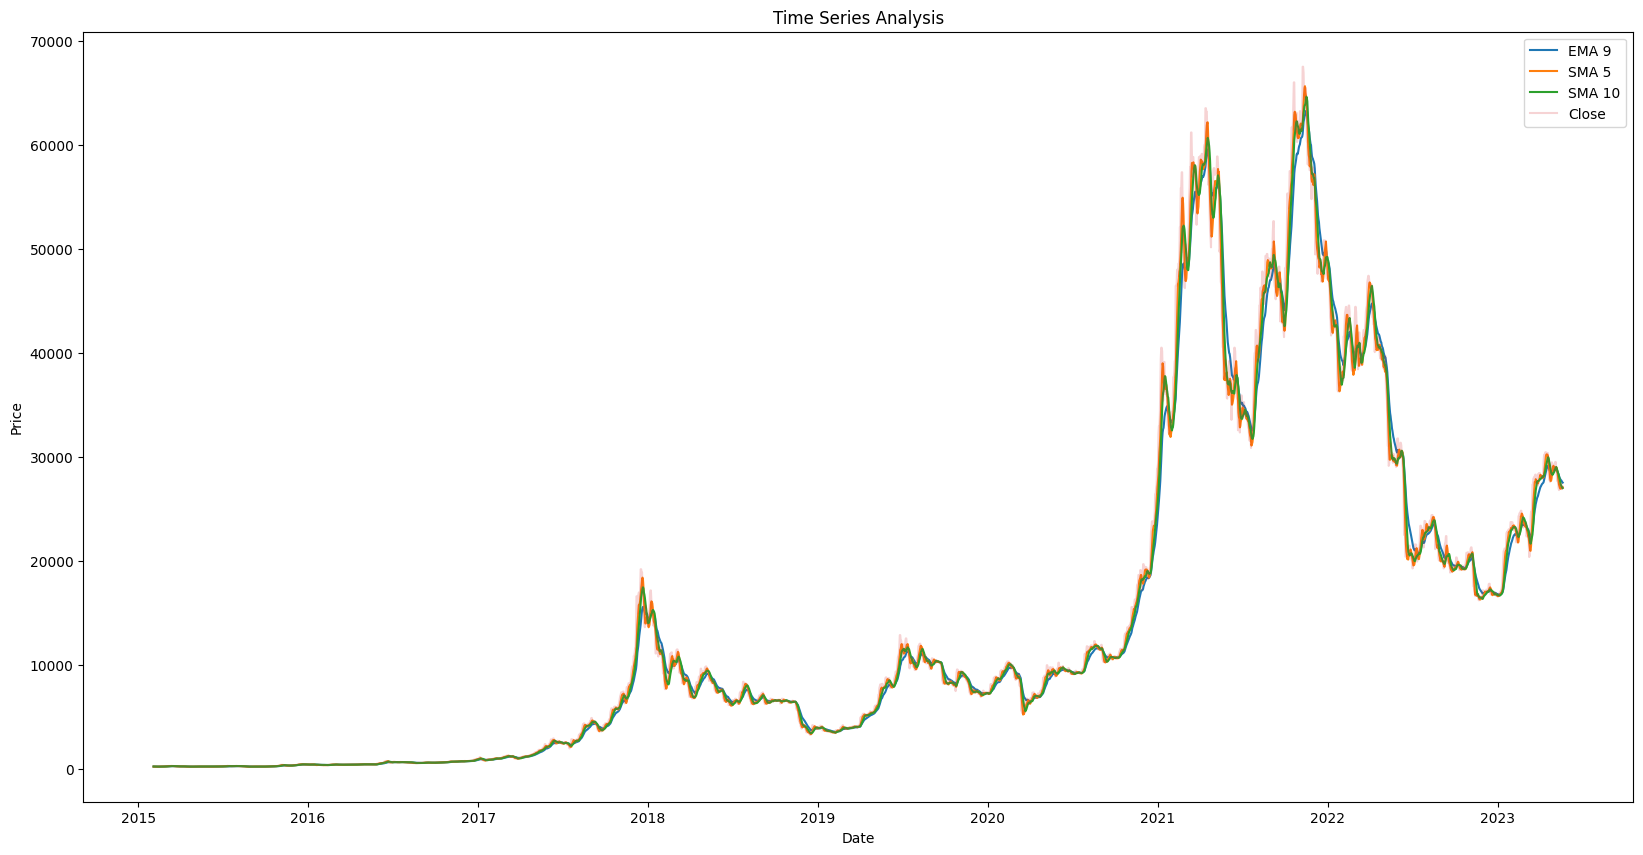

In [12]:
plt.figure(figsize=(20, 10))
plt.plot(df.index, df['EMA_9'], label='EMA 9')
plt.plot(df.index, df['SMA_5'], label='SMA 5')
plt.plot(df.index, df['SMA_10'], label='SMA 10')
plt.plot(df.index, df['Close2'], label='Close', alpha=0.2)

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Time Series Analysis')
plt.legend()

plt.show()

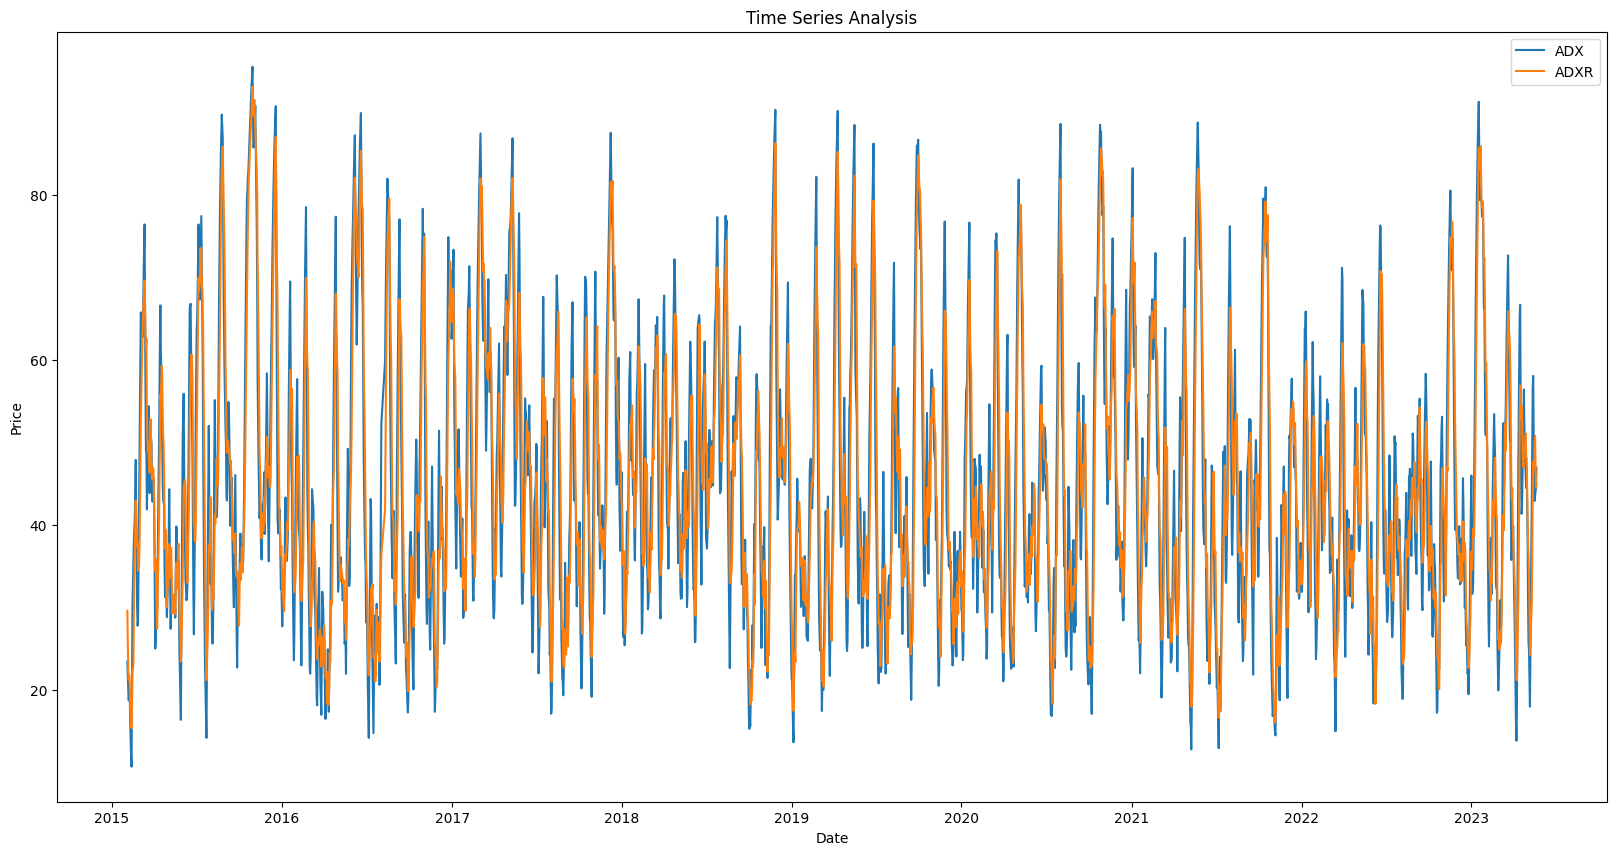

In [13]:
plt.figure(figsize=(20, 10))

plt.plot(df.index, df['ADX'],label='ADX')
plt.plot(df.index, df['ADXR'],label='ADXR')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Time Series Analysis')
plt.legend()

plt.show()

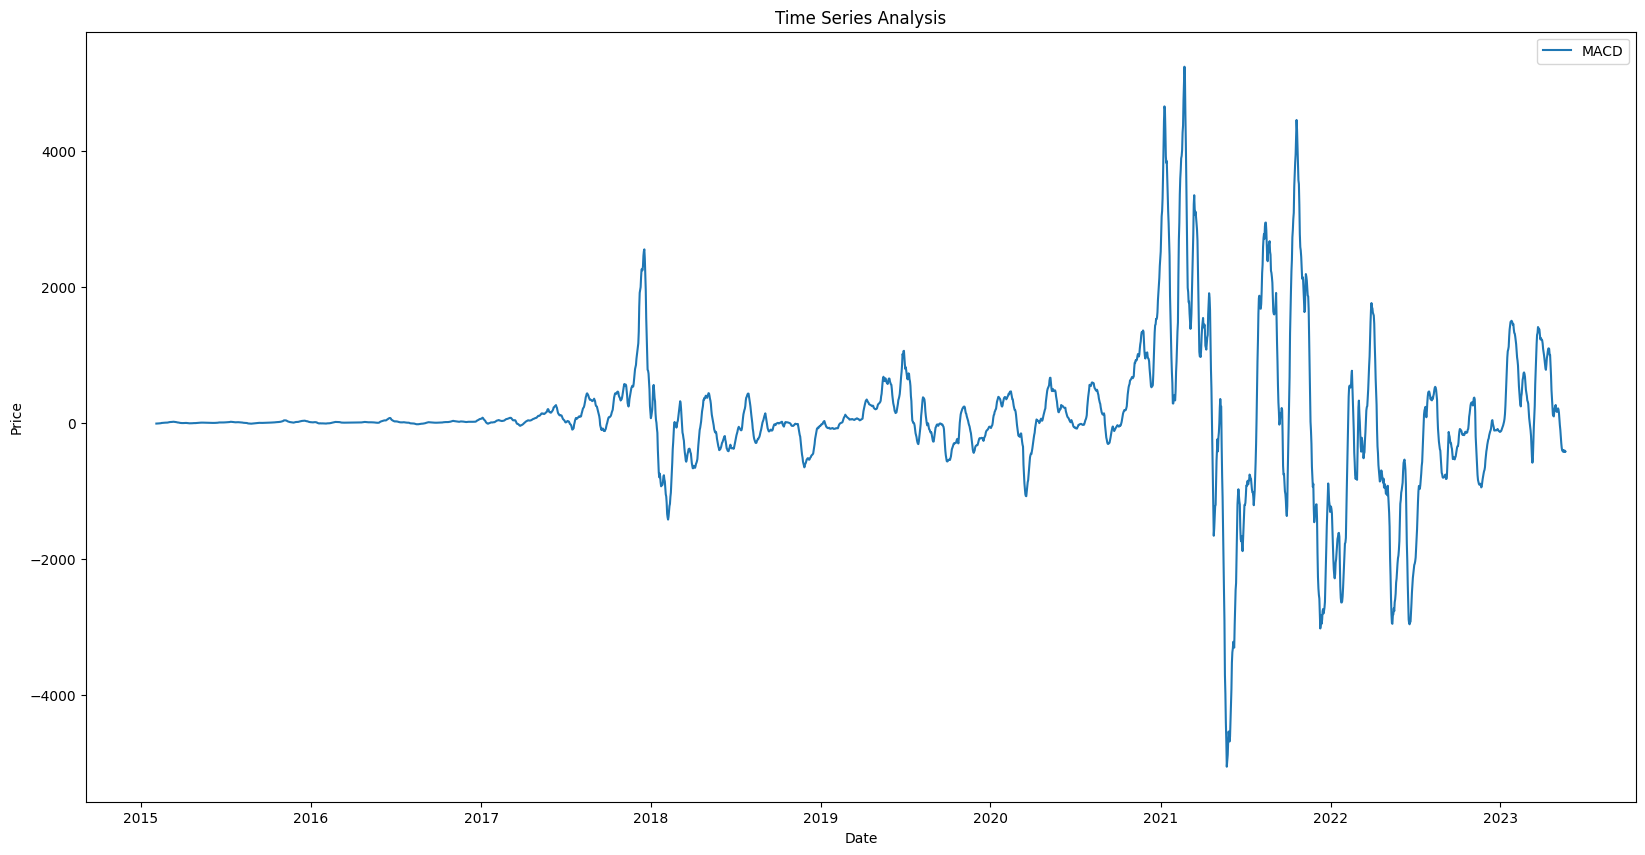

In [14]:

plt.figure(figsize=(20, 10))

plt.plot(df.index, df['MACD'],label='MACD')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Time Series Analysis')
plt.legend()

plt.show()

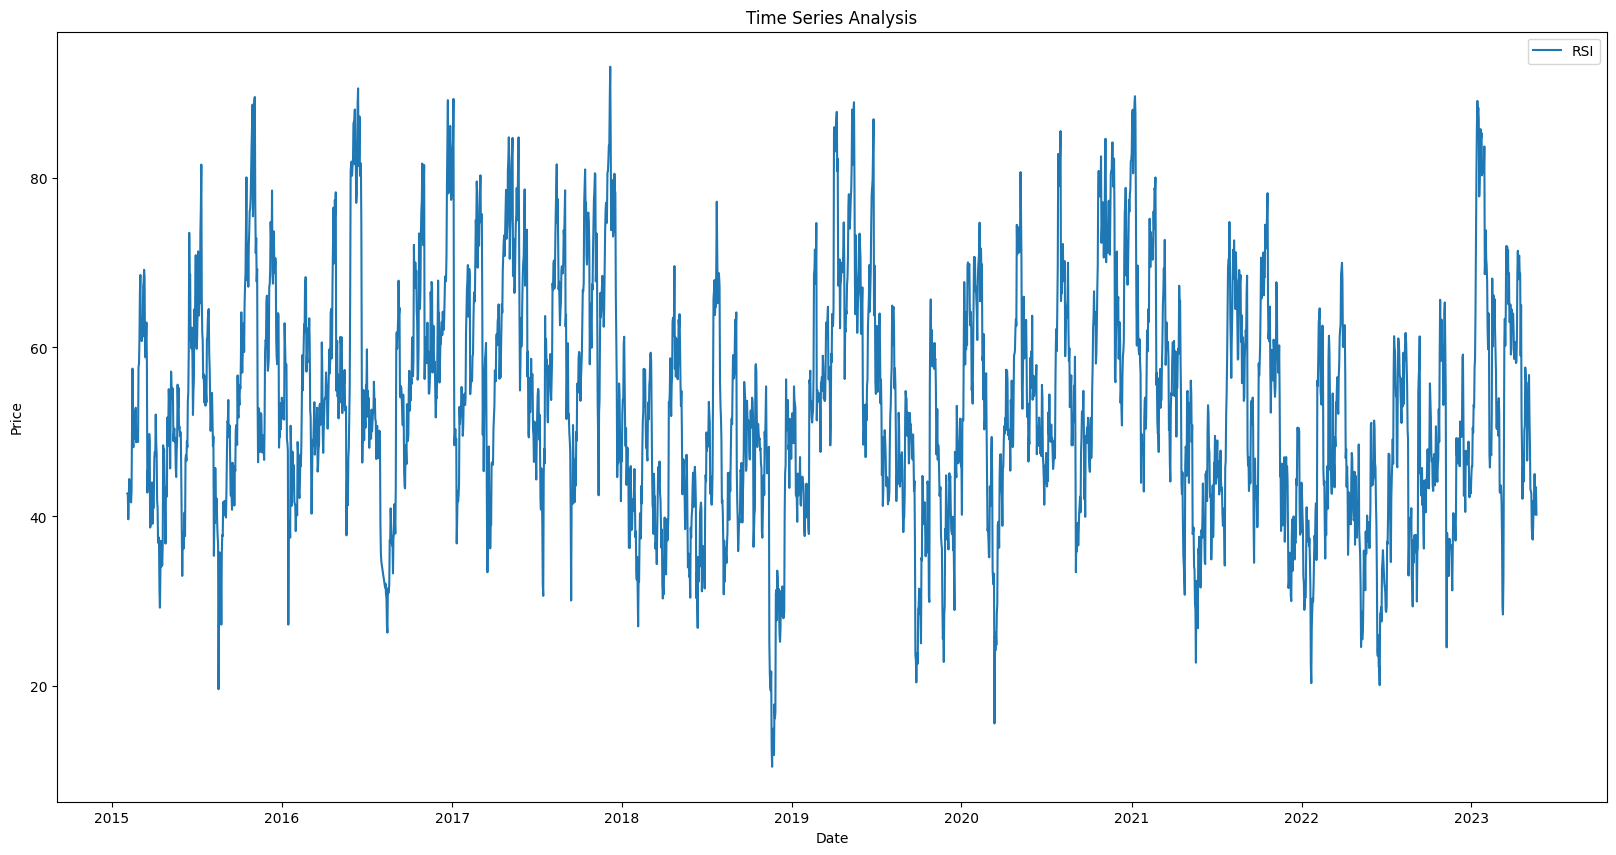

In [15]:
plt.figure(figsize=(20, 10))

plt.plot(df.index, df['RSI'],label='RSI')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Time Series Analysis')
plt.legend()

plt.show()

In [16]:
# fig, ax = plt.subplots(figsize=(20, 10))

# ax.plot(df.index, df['Close2'], label='Close')

# ax.plot(df.index, df['tenkan_sen'], label='Tenkan-sen')
# ax.plot(df.index, df['kijun_sen'], label='Kijun-sen')
# ax.plot(df.index, df['senkou_span_a'], label='Senkou Span A')
# ax.plot(df.index, df['senkou_span_b'], label='Senkou Span B')

# ax.legend()
# ax.set_title('Ichimoku Indicator')
# ax.set_xlabel('Date')
# ax.set_ylabel('Price')

# # Отображение графика
# plt.show()

In [17]:
train, test = train_test_split(df, WINDOW)
train_set, validation_set = train_validation_split(train, PERCENTAGE)

X_train, y_train, X_val, y_val = windowing(train_set, validation_set, WINDOW, PREDICTION_SCOPE)
X_train_f = X_train

In [18]:
#Convert the returned list into arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_val = np.array(X_val)
y_val = np.array(y_val)

In [19]:
#Reshaping the Data
X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)

[0]	validation_0-mae:13271.32066	validation_1-mae:25631.71066
[1]	validation_0-mae:12613.25685	validation_1-mae:24248.17160
[2]	validation_0-mae:11987.63908	validation_1-mae:22971.06417
[3]	validation_0-mae:11393.29183	validation_1-mae:21713.08371
[4]	validation_0-mae:10828.48892	validation_1-mae:20530.37277
[5]	validation_0-mae:10291.56724	validation_1-mae:19404.89035
[6]	validation_0-mae:9781.17350	validation_1-mae:18379.50167
[7]	validation_0-mae:9296.31816	validation_1-mae:17401.59152
[8]	validation_0-mae:8835.72785	validation_1-mae:16435.70675
[9]	validation_0-mae:8398.23838	validation_1-mae:15525.84347
[10]	validation_0-mae:7982.47993	validation_1-mae:14640.66769
[11]	validation_0-mae:7587.30687	validation_1-mae:13812.17062
[12]	validation_0-mae:7212.52845	validation_1-mae:13015.81124
[13]	validation_0-mae:6856.67252	validation_1-mae:12258.86789
[14]	validation_0-mae:6518.26304	validation_1-mae:11587.06124
[15]	validation_0-mae:6196.57143	validation_1-mae:10901.79074
[16]	validat

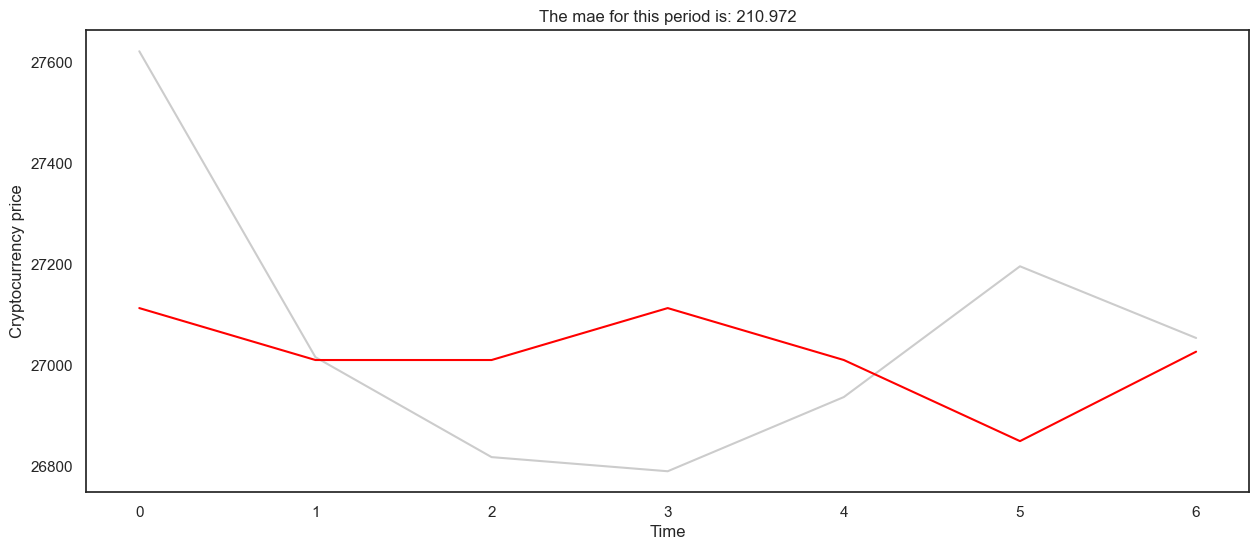

In [20]:
xgboost_mae, xgb_model, rmse, mse= xgb_model(X_train, y_train, X_val, y_val,model=None,retraing=False, plotting=True)
print("RMSE: ",rmse)
print("MSE: ",mse)

0:	learn: 15626.6798301	test: 15626.6798301	test1: 12326.3887524	best: 12326.3887524 (0)	total: 88.4ms	remaining: 1m 28s
1:	learn: 15111.8498601	test: 15111.8498601	test1: 11595.8867308	best: 11595.8867308 (1)	total: 95.2ms	remaining: 47.5s
2:	learn: 14612.6820859	test: 14612.6820859	test1: 10919.0802028	best: 10919.0802028 (2)	total: 102ms	remaining: 34s
3:	learn: 14135.8107435	test: 14135.8107435	test1: 10493.1924948	best: 10493.1924948 (3)	total: 109ms	remaining: 27.1s
4:	learn: 13671.8205460	test: 13671.8205460	test1: 9863.2510531	best: 9863.2510531 (4)	total: 116ms	remaining: 23s
5:	learn: 13229.4780741	test: 13229.4780741	test1: 9595.2089681	best: 9595.2089681 (5)	total: 122ms	remaining: 20.3s
6:	learn: 12797.7164850	test: 12797.7164850	test1: 8965.0786362	best: 8965.0786362 (6)	total: 129ms	remaining: 18.3s
7:	learn: 12390.6493038	test: 12390.6493038	test1: 8687.5067426	best: 8687.5067426 (7)	total: 136ms	remaining: 16.9s
8:	learn: 11987.7426731	test: 11987.7426731	test1: 8051.6

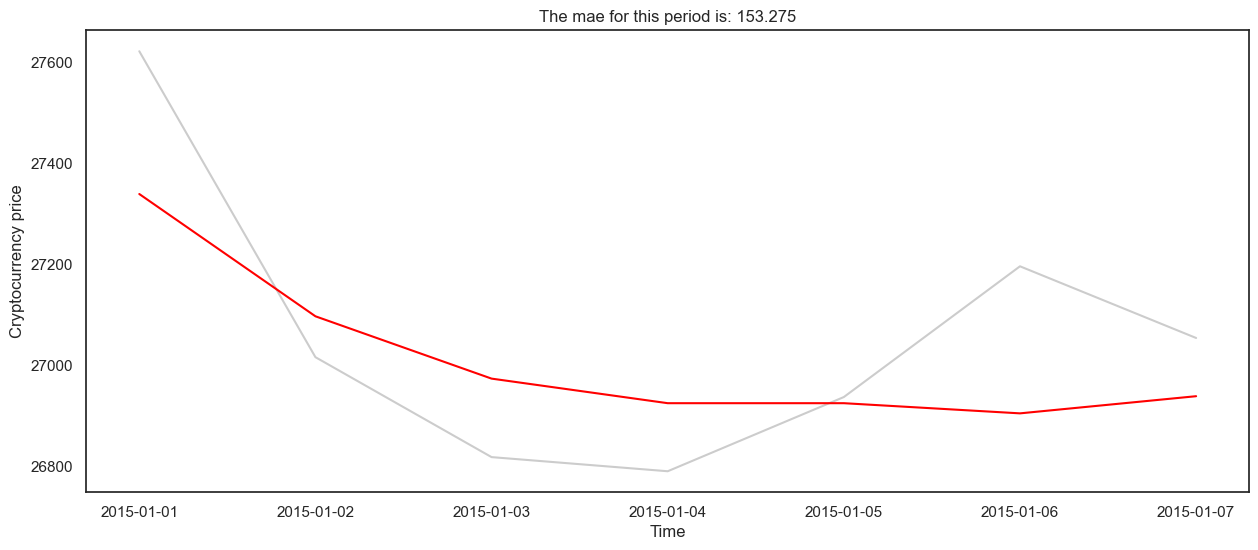

In [21]:
catboost_mae, cat_model,catboost_rmse, catboost_mse= catboost_model(X_train, y_train, X_val, y_val,retraing=False, plotting=True)
print("RMSE: ",catboost_rmse)
print("MSE: ",catboost_mse)

In [22]:
feature_importances = cat_model.get_feature_importance()
X_train_f = pd.DataFrame(X_train)
feature_names = X_train_f.columns

# Создание DataFrame с важностью признаков
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Сортировка по убыванию важности
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

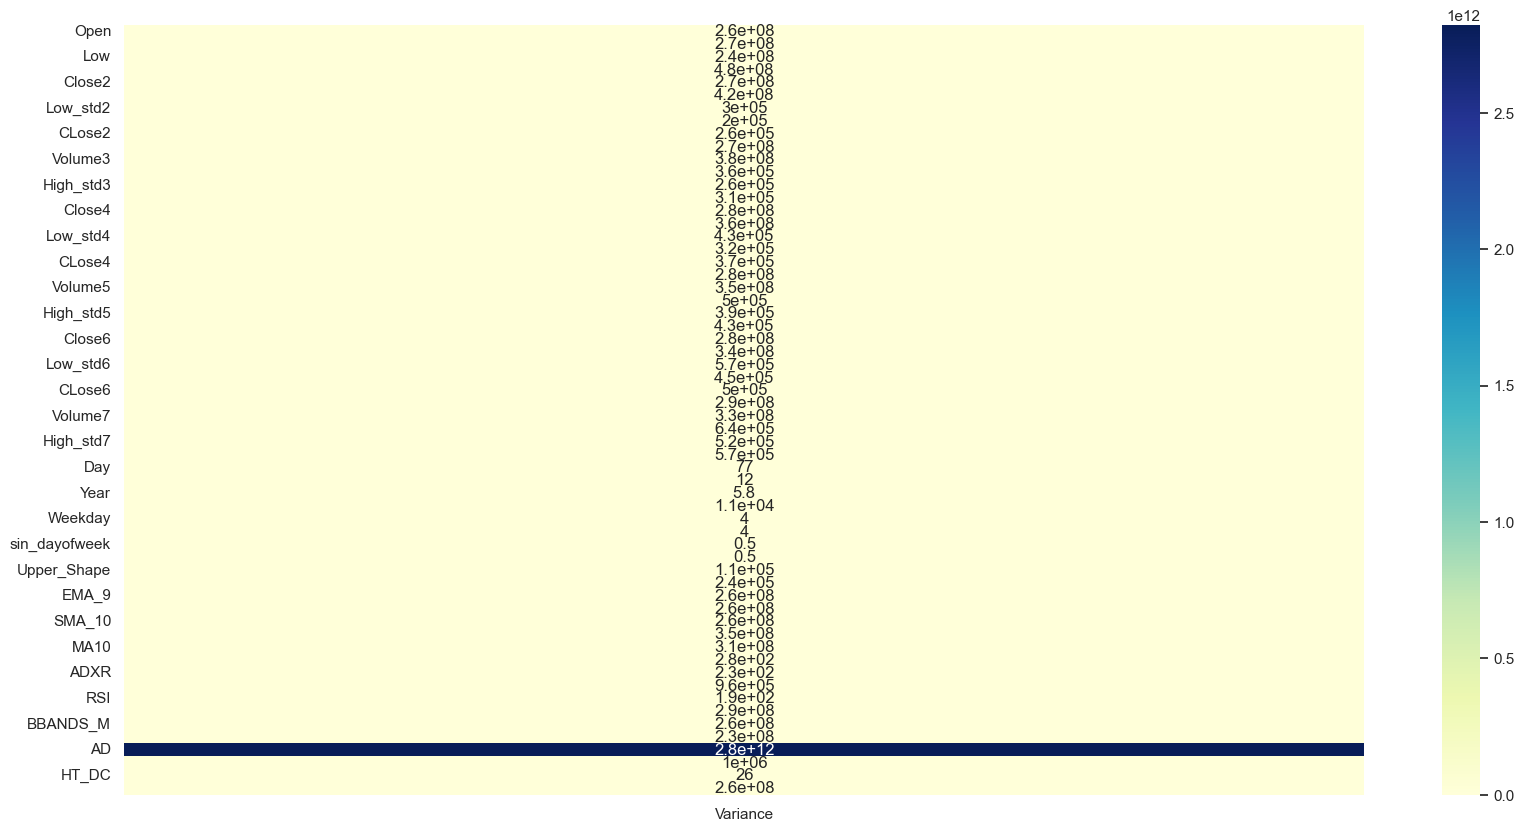

In [23]:
# Вычисление матрицы дисперсии
variance_matrix = df.var()

# Преобразование матрицы дисперсии в DataFrame
variance_df = pd.DataFrame(variance_matrix, columns=['Variance'])

# Установка размера графика
fig, ax = plt.subplots(figsize=(20, 10))

# Использование Seaborn для отображения матрицы дисперсии
sns.heatmap(variance_df, annot=True, cmap='YlGnBu', ax=ax)

# Отображение графика
plt.show()

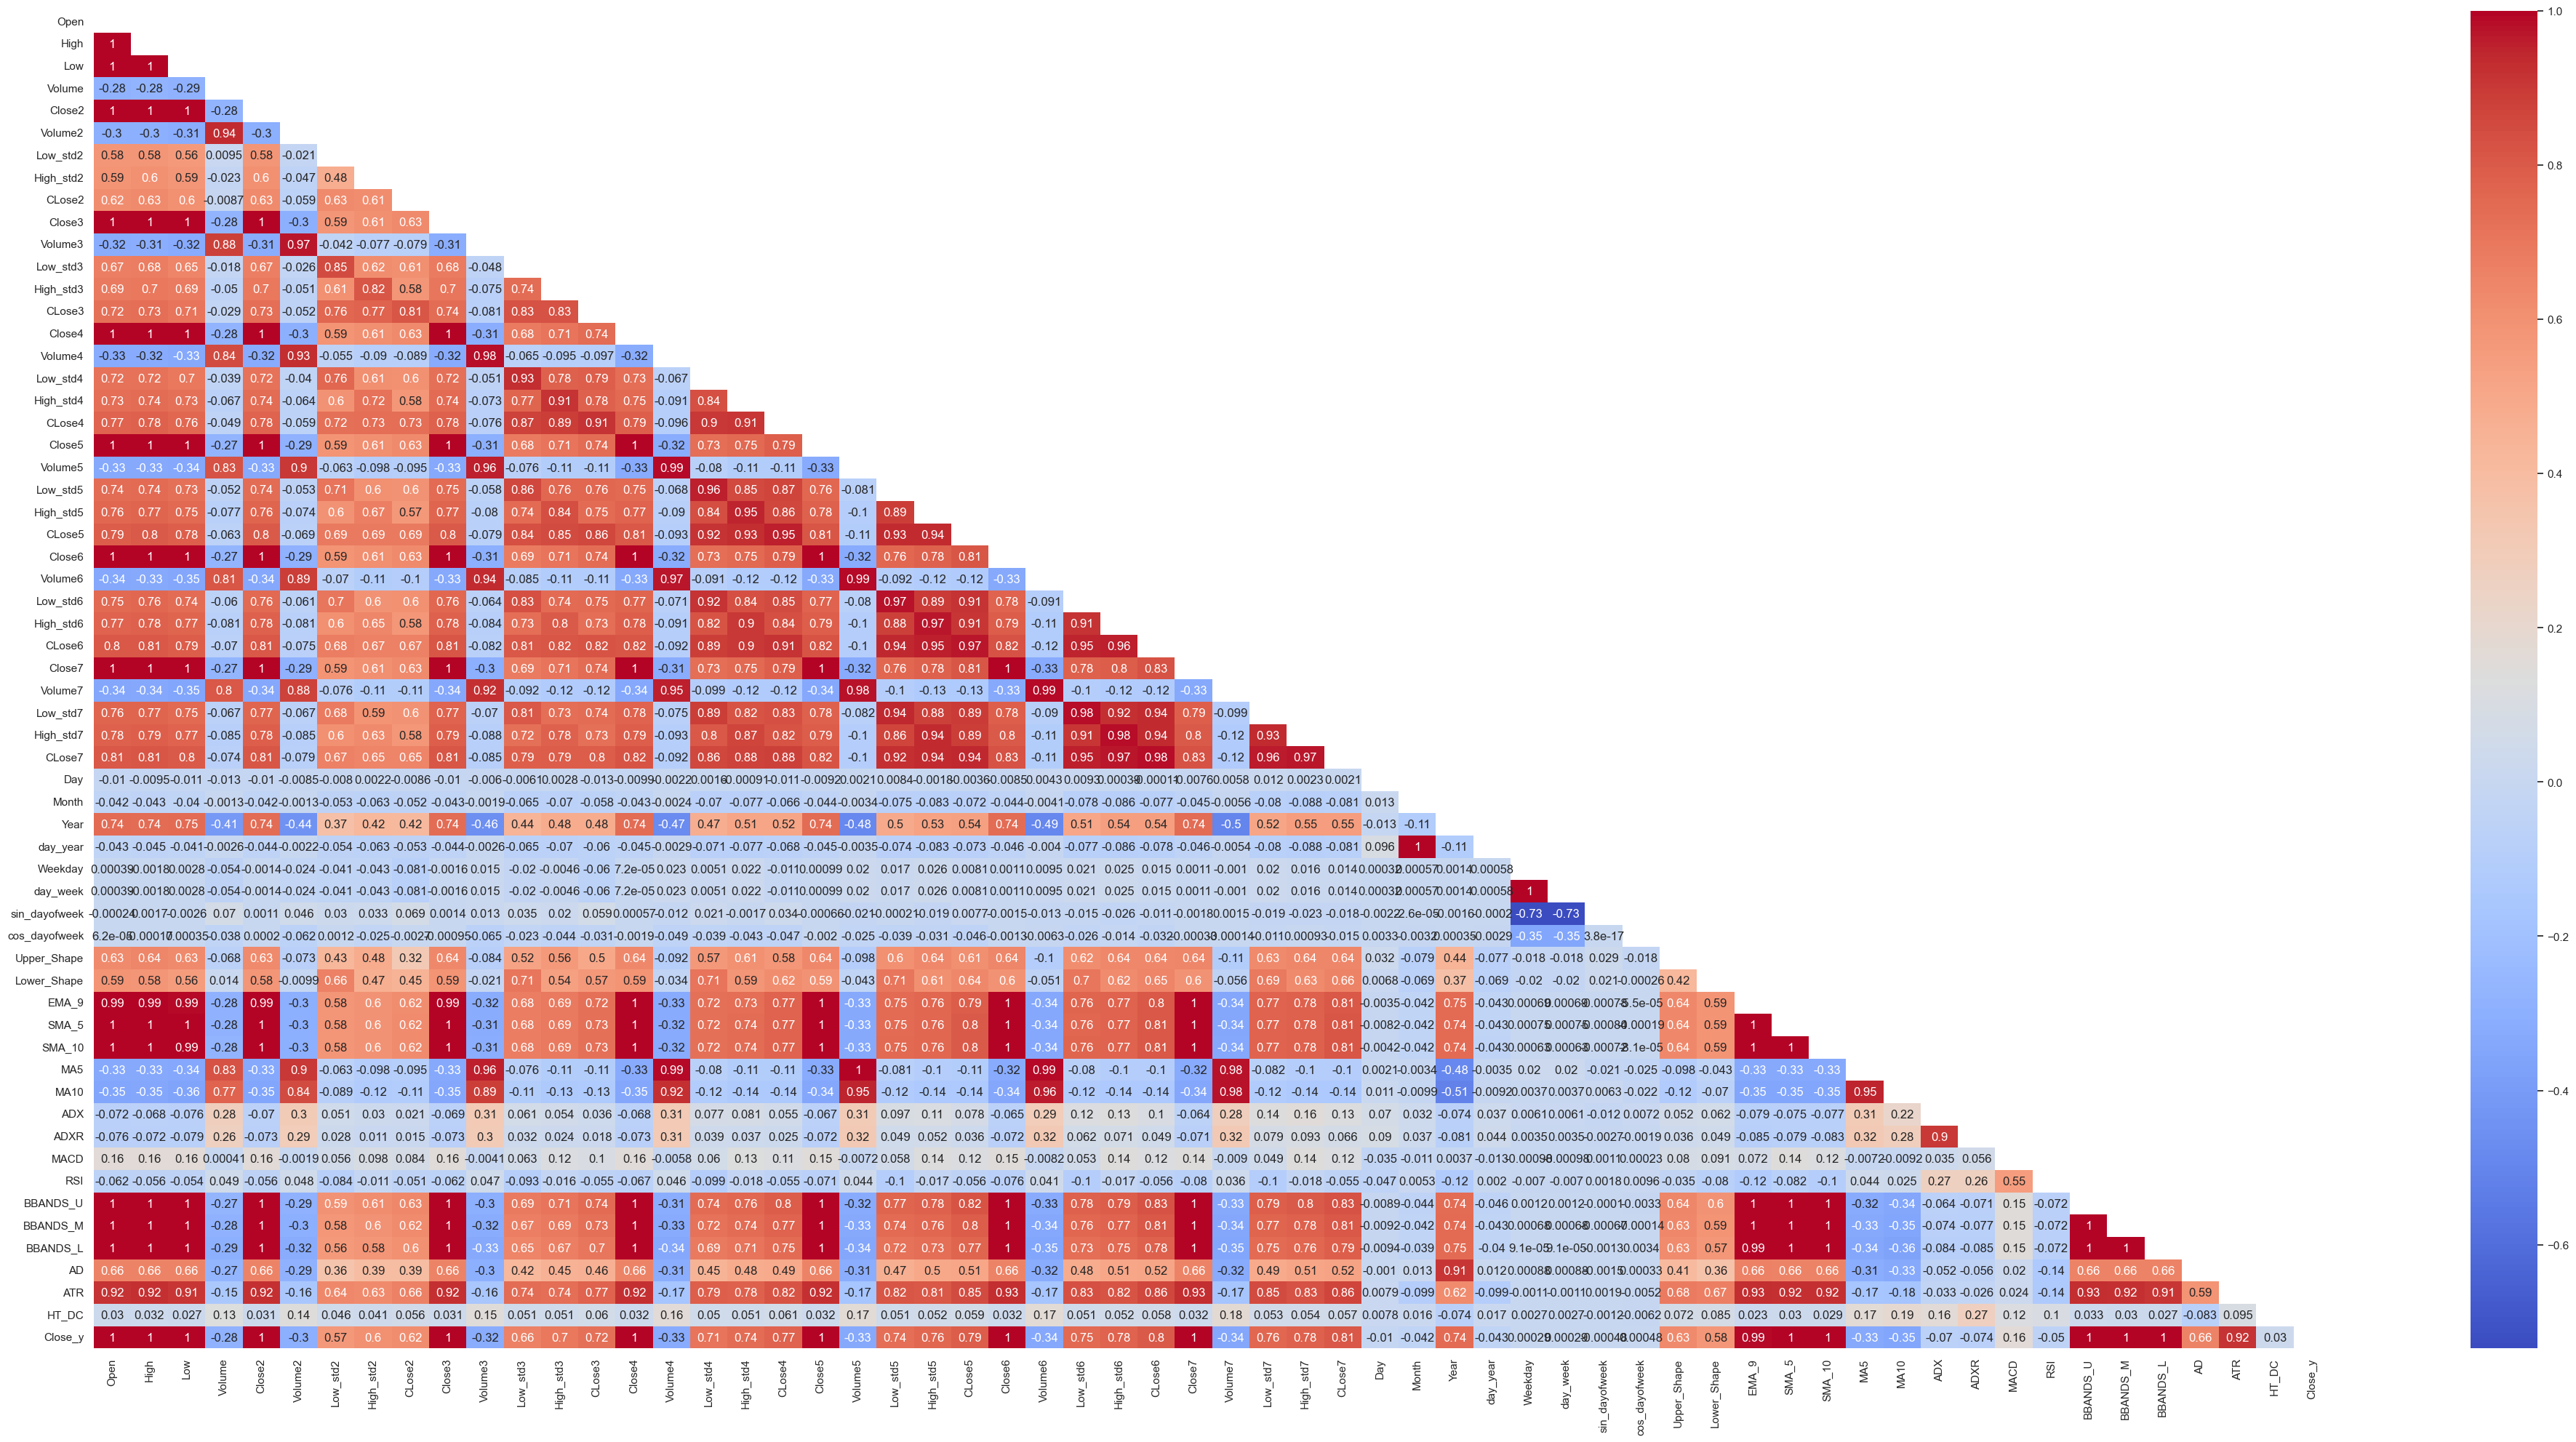

In [24]:
# Compute the correlation matrix
corr_matrix = df.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the correlation matrix
plt.figure(figsize=(40, 20))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm')

# Plot feature importance on the right side of the correlation matrix
ax = plt.gca()
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
feature_names = feature_importance_df['Feature']
feature_importance = feature_importance_df['Importance']
# for i, feature in enumerate(feature_names):
#     ax.text(len(df.columns) + 1, i + 0.5, feature, ha='left', va='center')
#     ax.text(len(df.columns) + 2, i + 0.5, f'{feature_importance[i]:.2f}', ha='left', va='center')

plt.tight_layout()
plt.show()

RMSE:  1771.4509370108847
MSE:  3138038.422236741
MAPE:  0.0647672955066957


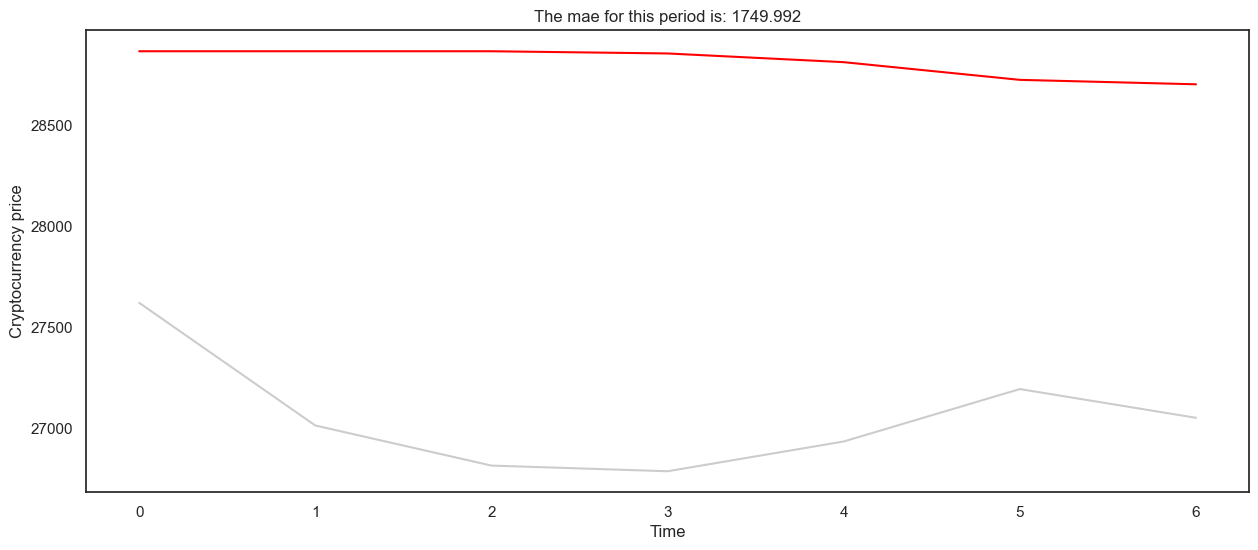

In [25]:
mae3, random_forest, forest_rmse , forest_mse, forest_mape = random_forest_model(X_train, y_train, X_val, y_val,retraing=False, plotting=True)
print("RMSE: ", forest_rmse)
print("MSE: ", forest_mse)
print("MAPE: " , forest_mape)

In [26]:
X_test = np.array(test.iloc[:, :-1])
y_test = np.array(test.iloc[:, -1])
X_test = X_test.reshape(1, -1)

In [27]:
pred_test_xgb = xgb_model.predict(X_test)
pred_test_catboots = cat_model.predict(X_test)

In [28]:
plotting(df,y_val, y_test, pred_test_catboots, catboost_mae, catboost_mape, catboost_rmse,catboost_mse ,WINDOW, PREDICTION_SCOPE)

NameError: name 'catboost_mape' is not defined

In [ ]:
scope = predictions(catboost_mae,xgboost_mae,pred_test_catboots,pred_test_catboots)
avg_mae = (catboost_mae + xgboost_mae)/2

In [ ]:
plotting(df,y_val, y_test, scope, avg_mae, WINDOW, PREDICTION_SCOPE)

TypeError: plotting() missing 3 required positional arguments: 'mse', 'WINDOW', and 'PREDICTION_SCOPE'